0.07692307692307693
0.13333333333333333
(np.float64(0.01779451548319153), np.float64(0.3386844899318212))


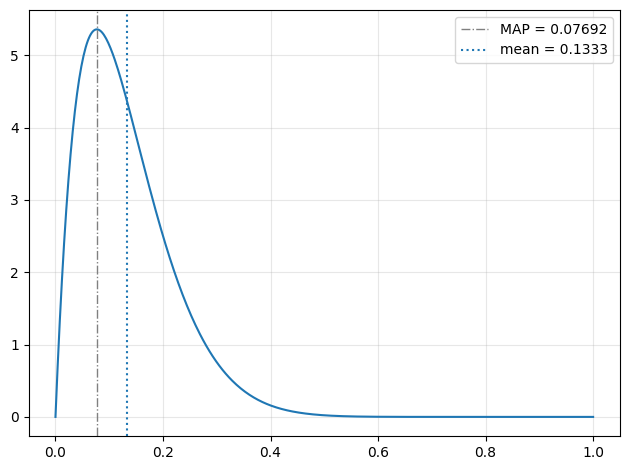

In [15]:
from scipy import stats

# Beta(1,1) prior + (1 encounter, 12 misses) → Beta(2, 13)
posterior = stats.beta(2, 13)

print(1/13) # Mode 0.07692
print(posterior.mean())              # 0.1333
print(posterior.interval(0.95))      # (0.0178, 0.3387)

# plot the whole thing
import numpy as np, matplotlib.pyplot as plt
theta = np.linspace(0, 1, 500)
plt.plot(theta, posterior.pdf(theta))
plt.axvline(1/13, color="grey", linestyle="-.", linewidth=1, label="MAP = 0.07692")
plt.axvline(2/15, ls=":",  label="mean = 0.1333")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)

Posterior mean : 0.1499
Posterior MAP  : 0.1310


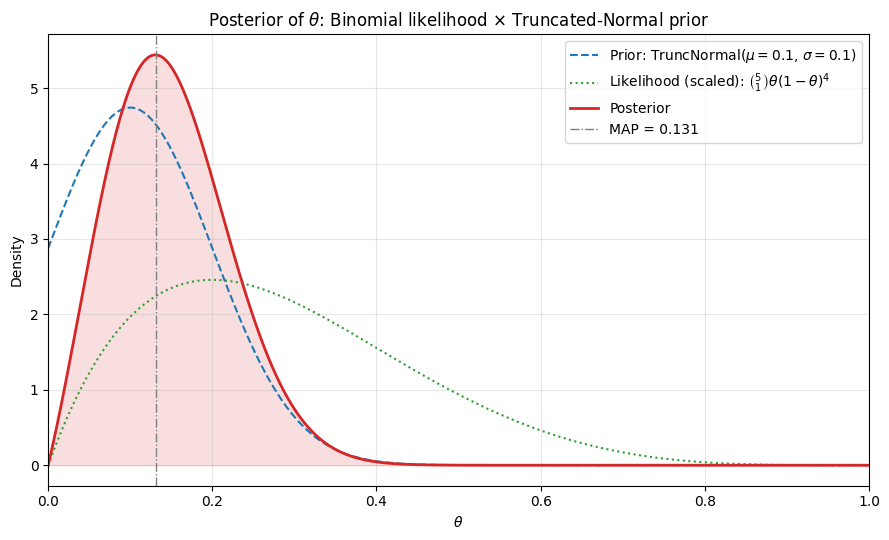

In [3]:
"""
Bayesian inference on a grid.

Likelihood : Binomial  L(theta) = C(5,1) * theta^1 * (1-theta)^4
Prior      : Truncated Normal on [0, 1] with mu = 0.1, sigma = 0.1
Posterior  : posterior(theta)  ∝  likelihood(theta) * prior(theta)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
from scipy.special import comb

# ------------------------------------------------------------------
# 1. Grid of theta values on [0, 1]
# ------------------------------------------------------------------
theta = np.linspace(0, 1, 1001)

# ------------------------------------------------------------------
# 2. Binomial likelihood: n = 5 trials, k = 1 success
# ------------------------------------------------------------------
n, k = 5, 1
likelihood = comb(n, k) * theta**k * (1 - theta)**(n - k)

# ------------------------------------------------------------------
# 3. Truncated normal prior on [0, 1], mu = 0.1, sigma = 0.1
#    (scipy's truncnorm takes bounds in standard-normal units)
# ------------------------------------------------------------------
mu, sigma = 0.1, 0.1
a, b = (0 - mu) / sigma, (1 - mu) / sigma
prior = truncnorm.pdf(theta, a, b, loc=mu, scale=sigma)

# ------------------------------------------------------------------
# 4. Posterior ∝ likelihood × prior, normalised numerically
#    (trapezoidal rule so it integrates to 1)
# ------------------------------------------------------------------
unnormalised = likelihood * prior
posterior = unnormalised / np.trapezoid(unnormalised, theta)

# Summary statistics
post_mean = np.trapezoid(theta * posterior, theta)
post_map = theta[np.argmax(posterior)]
print(f"Posterior mean : {post_mean:.4f}")
print(f"Posterior MAP  : {post_map:.4f}")

# ------------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(theta, prior, "--", color="tab:blue",
        label=fr"Prior: TruncNormal($\mu={mu}$, $\sigma={sigma}$)")
ax.plot(theta, likelihood / np.trapezoid(likelihood, theta), ":",
        color="tab:green",
        label=r"Likelihood (scaled): $\binom{5}{1}\theta(1-\theta)^4$")
ax.plot(theta, posterior, "-", color="tab:red", linewidth=2,
        label="Posterior")
ax.fill_between(theta, posterior, alpha=0.15, color="tab:red")

ax.axvline(post_map, color="grey", linestyle="-.", linewidth=1,
           label=f"MAP = {post_map:.3f}")

ax.set_xlabel(r"$\theta$")
ax.set_ylabel("Density")
ax.set_title("Posterior of $\\theta$: Binomial likelihood × Truncated-Normal prior")
ax.set_xlim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("posterior_plot.png", dpi=150)
plt.show()

Posterior mean : 0.1499
Posterior MAP  : 0.1310
95% interval   : [0.0308, 0.3078]


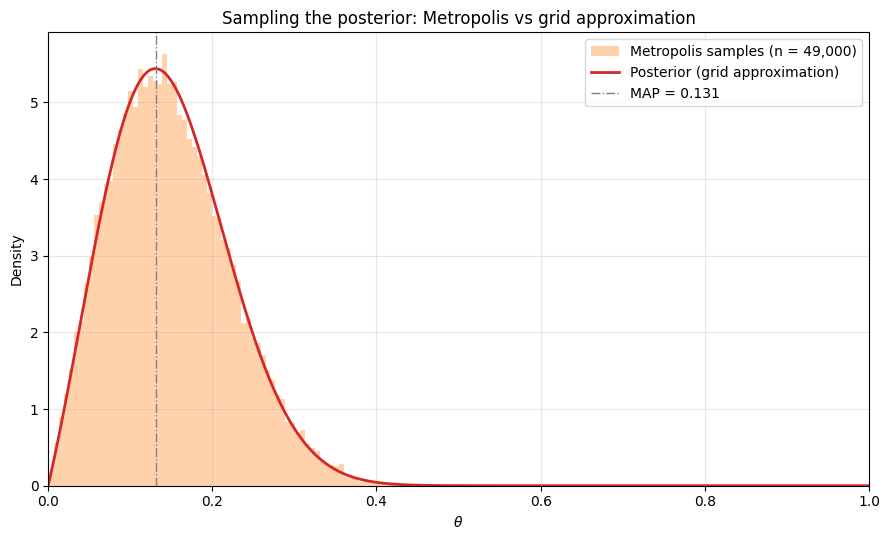

In [24]:
"""
Bayesian inference by sampling (Metropolis algorithm).
Likelihood : Binomial  L(theta) = C(5,1) * theta^1 * (1-theta)^4
Prior      : Truncated Normal on [0, 1] with mu = 0.1, sigma = 0.1
Posterior  : approximated by sampling -- no normalisation constant needed
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
from scipy.special import comb

rng = np.random.default_rng(42)

# ------------------------------------------------------------------
# 1. Same likelihood and prior as the grid example
# ------------------------------------------------------------------
n, k = 5, 1
mu, sigma = 0.1, 0.1
a, b = (0 - mu) / sigma, (1 - mu) / sigma


def likelihood(theta):
    return comb(n, k) * theta**k * (1 - theta)**(n - k)


def prior(theta):
    # truncnorm returns 0 outside [0, 1], so out-of-range
    # proposals are rejected automatically
    return truncnorm.pdf(theta, a, b, loc=mu, scale=sigma)


def unnormalised_posterior(theta):
    return likelihood(theta) * prior(theta)


# ------------------------------------------------------------------
# 2. Metropolis algorithm: a random walk over theta
# ------------------------------------------------------------------
n_steps = 50_000
step_size = 0.05        # std-dev of the Gaussian proposal
current = 0.5           # arbitrary starting point
samples = []

for _ in range(n_steps):
    proposal = current + rng.normal(0, step_size)
    ratio = unnormalised_posterior(proposal) / unnormalised_posterior(current)
    if rng.uniform() < ratio:   # uphill: always, downhill: with prob = ratio
        current = proposal
    samples.append(current)     # record even when the proposal is rejected

# ------------------------------------------------------------------
# 3. Discard burn-in (the walk from the start point to the bulk)
# ------------------------------------------------------------------
burn_in = 1_000
samples = np.array(samples[burn_in:])

# Summary statistics -- straight from the samples, no integration
post_mean = samples.mean()
post_map = theta[np.argmax(posterior)]

ci_low, ci_high = np.percentile(samples, [2.5, 97.5])
print(f"Posterior mean : {post_mean:.4f}")
print(f"Posterior MAP  : {post_map:.4f}")
print(f"95% interval   : [{ci_low:.4f}, {ci_high:.4f}]")

# ------------------------------------------------------------------
# 4. Ground truth from the grid example, for comparison
# ------------------------------------------------------------------
theta = np.linspace(0, 1, 1001)
unnormalised = likelihood(theta) * prior(theta)
posterior = unnormalised / np.trapezoid(unnormalised, theta)

# ------------------------------------------------------------------
# 5. Plot: sample histogram vs grid posterior
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(samples, bins=80, density=True, alpha=0.35, color="tab:orange",
        label=f"Metropolis samples (n = {len(samples):,})")
ax.plot(theta, posterior, "-", color="tab:red", linewidth=2,
        label="Posterior (grid approximation)")
ax.axvline(post_map, color="grey", linestyle="-.", linewidth=1,
           label=f"MAP = {post_map:.3f}")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("Density")
ax.set_title("Sampling the posterior: Metropolis vs grid approximation")
ax.set_xlim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("metropolis_plot.png", dpi=150)
plt.show()

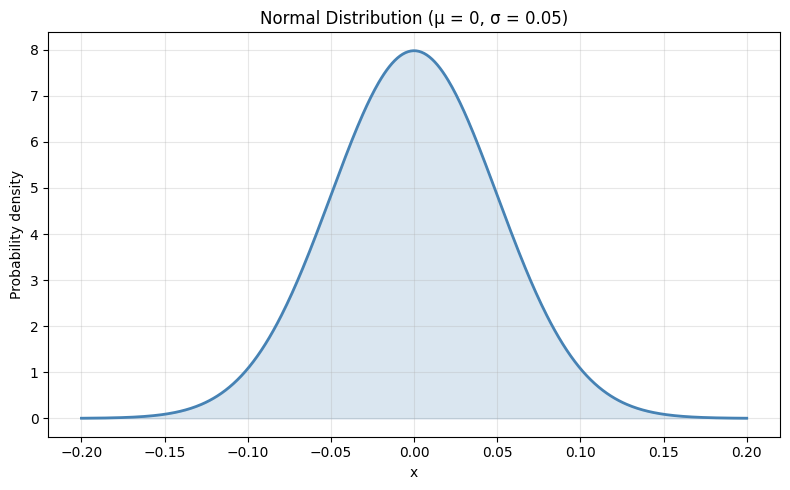

In [22]:
# Visualistaion of the Proposal distribution
# N(mu=0, std=0.05)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma = 0, 0.05
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='steelblue', linewidth=2)
plt.fill_between(x, y, alpha=0.2, color='steelblue')
plt.title('Normal Distribution (μ = 0, σ = 0.05)')
plt.xlabel('x')
plt.ylabel('Probability density')
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [27]:
# first 5 steps of the MH

n_steps = 5
step_size = 0.05
current = 0.5
samples = []

for _ in range(n_steps):
    proposal = current + rng.normal(0, step_size)
    print(f"proposal: {proposal}")
    ratio = unnormalised_posterior(proposal) / unnormalised_posterior(current)
    print(f"ratio: {ratio}")
    if rng.uniform() < ratio:
        print(f"accepted: current={proposal}")
        current = proposal
    else:
        print("rejected")
    samples.append(current)


proposal: 0.5207738876475073
ratio: 0.37472321449483587
rejected
proposal: 0.5106677452347335
ratio: 0.6080158660811117
accepted: current=0.5106677452347335
proposal: 0.4750292068030035
ratio: 4.9973877117575025
accepted: current=0.4750292068030035
proposal: 0.4325111992605819
ratio: 5.595182105753271
accepted: current=0.4325111992605819
proposal: 0.368528287066306
ratio: 8.93566538454108
accepted: current=0.368528287066306
